In [1]:
# Importing packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import os

# Setting up a plotting directory in the repository
plot_dir = os.path.join("..", "plots", "eda")
os.makedirs(plot_dir, exist_ok=True)

In [2]:
""" Global parameters """

# Answer to the universe 
np.random.seed(42)

# Data path
DATA_PATH = "../data/raw/DAT_NT_EURDKK_T_LAST_202601.csv"

In [3]:
""" Building the data """

# Reading CSV data from data path and parsing
# it using ";" while renaming column headers 
# also chaining it for efficiency
df = (
    pd.read_csv(
        DATA_PATH,
        sep=";",
        header=None,
        names=["datetime", "last", "volume"],
        parse_dates=["datetime"],
        date_format="%Y%m%d %H%M%S",
        index_col="datetime",
        usecols=["datetime", "last"],
    )
    .loc["2026-01-05":"2026-01-09", "last"]
    .resample("1s")
    .ohlc()
    .dropna()
)

# Retrieving the days 
days = df.index.normalize().unique().strftime("%Y-%m-%d")

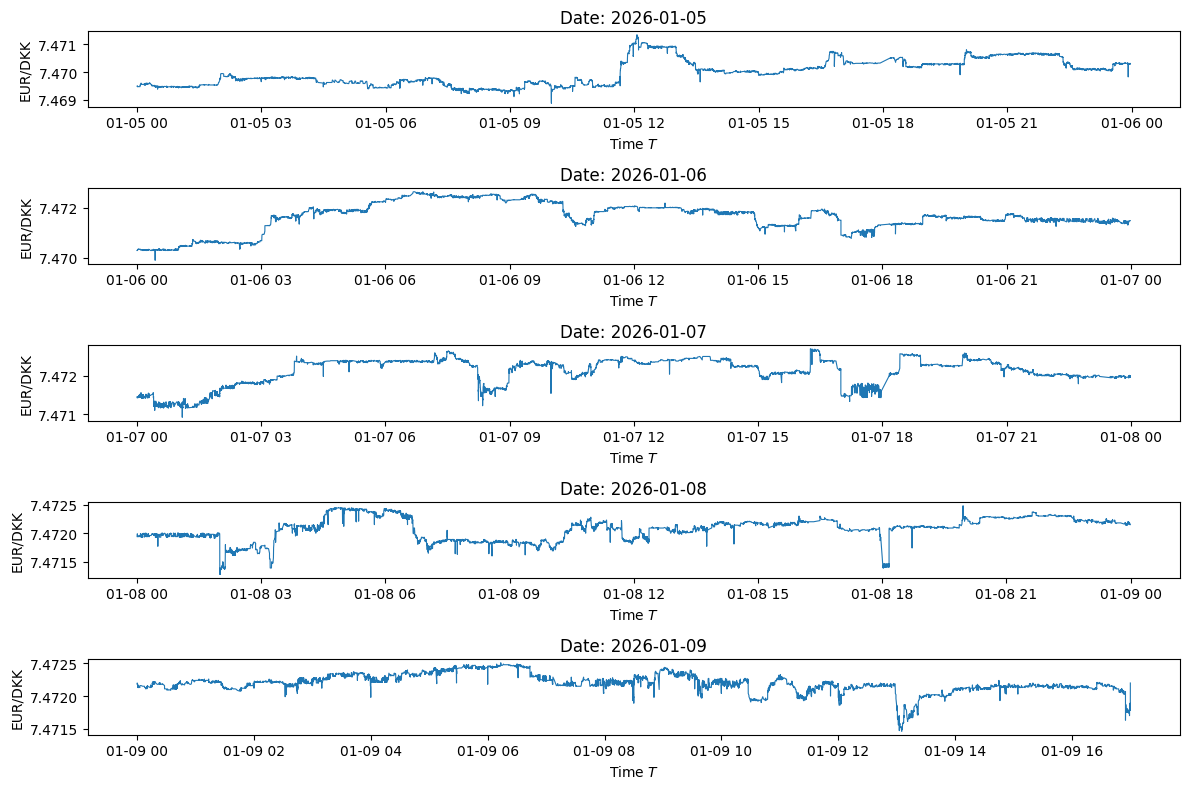

In [4]:
""" Plotting figure """

# Setting up figure and axes
fig, axes = plt.subplots(len(days), 1, figsize=(12, 8), sharex=False)

# Looping through each of the panels
for ax, day in zip(axes, days):

    # Day data
    day_data = df.loc[day]
    
    # Plotting the time series
    ax.plot(day_data.index, day_data["close"], linewidth=0.8)

    # Setting title and axes labels
    ax.set_title(f"Date: {day}")
    ax.set_xlabel("Time $T$")
    ax.set_ylabel("EUR/DKK")

# Tight layout
plt.tight_layout()

# Saving and showing the figure
plt.savefig(os.path.join(plot_dir, f"eurdkk.pdf"), bbox_inches="tight")
plt.show()
